# A1 - PyTorch refresher: the training loop you'll reuse everywhere

**Goal.** Re-ground the basics you saw in *Intermediate Deep Learning with PyTorch*:
a model is an `nn.Module`, data comes from a `DataLoader`, and *training is a loop*
(forward -> loss -> `backward()` -> `optimizer.step()`).

Everything later in this repo - the ResNet (A2), the RNN (A3), the policy/value
net (A4) and even the supervised step *inside* AlphaZero self-play - is this same
loop. We keep it in one place: `azl.foundations.train_loop.fit`.

> **Maps to raccoon:** the SGD step in `raccoon/train/coach.py` `training_phase`
> is exactly this loop, just with a two-part loss (see A4).

In [1]:
import matplotlib.pyplot as plt
import torch

from azl.foundations.data import mnist_loaders
from azl.foundations.models import MLP
from azl.foundations.train_loop import fit, count_parameters

torch.manual_seed(0)

# A subset keeps this fast; raise num_train (or drop it) for the full dataset.
train_loader, test_loader = mnist_loaders(batch_size=128, view="flat", num_train=8000)
print("one batch:", next(iter(train_loader))[0].shape)  # (B, 784) flattened digits

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 65.5k/9.91M [00:00<00:17, 579kB/s]

  1%|▏         | 131k/9.91M [00:00<00:17, 546kB/s] 

  2%|▏         | 197k/9.91M [00:00<00:19, 491kB/s]

  4%|▍         | 426k/9.91M [00:00<00:09, 972kB/s]

...

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.04MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 1.78MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

one batch: torch.Size([128, 784])


In [2]:
model = MLP(in_features=784, hidden=256, num_classes=10)
print(f"{count_parameters(model):,} parameters")

history = fit(model, train_loader, test_loader, epochs=5, lr=1e-3)

269,322 parameters


epoch  1/5  train_loss 0.6406  val_loss 0.3408  val_acc 0.8956


epoch  2/5  train_loss 0.2485  val_loss 0.2565  val_acc 0.9240


epoch  3/5  train_loss 0.1701  val_loss 0.2548  val_acc 0.9198


epoch  4/5  train_loss 0.1212  val_loss 0.2169  val_acc 0.9331


epoch  5/5  train_loss 0.0838  val_loss 0.2109  val_acc 0.9354


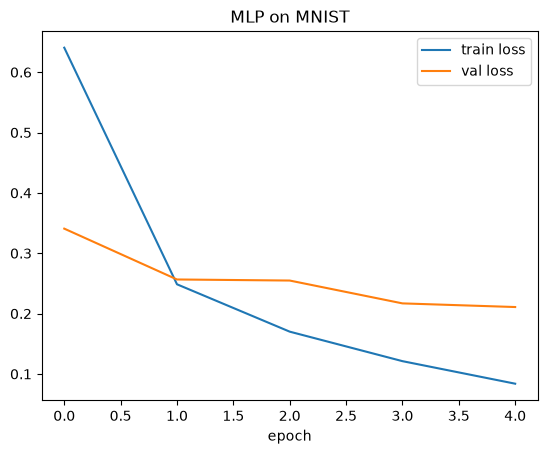

final test accuracy: 0.9354


In [3]:
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.legend(); plt.title("MLP on MNIST"); plt.show()
print("final test accuracy:", history["val_acc"][-1])

### Things to tweak
- `hidden`, `epochs`, `lr`, `num_train` - watch the loss curve and accuracy move.
- Switch `view="image"` and feed the same MLP (it flattens internally).

### Takeaway
A plain MLP already gets MNIST mostly right, but it throws away the 2D structure of
the image. The next notebook adds an inductive bias that *uses* that structure -
convolutions and residual blocks - which is the trunk raccoon's network is built
from.